# STEP 1 — INSTALL LIBRARIES

In [4]:


!pip install prophet xgboost holidays statsmodels openpyxl

# STEP 2 — IMPORT LIBRARIES

In [5]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import holidays
import warnings

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

# STEP 3 — LOAD DATASET

In [6]:


df = pd.read_csv('/content/Forecasting Case- Study.xlsx - Sheet1.csv')

# STEP 4 — CHECK DATA

In [7]:
print(df.head())

print(df.columns)

print(df.info())

        State       Date           Total   Category
0     Alabama  1/12/2019    109,574,036   Beverages
1     Arizona  1/12/2019    109,101,595   Beverages
2    Arkansas  1/12/2019     58,049,432   Beverages
3  California  1/12/2019    444,766,891   Beverages
4    Colorado  1/12/2019     89,816,716   Beverages
Index(['State', 'Date', 'Total', 'Category'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   State     8084 non-null   object
 1   Date      8084 non-null   object
 2   Total     8084 non-null   object
 3   Category  8084 non-null   object
dtypes: object(4)
memory usage: 252.8+ KB
None


# STEP 5 — RENAME COLUMNS

In [8]:
df.rename(columns={
    'Date': 'date',
    'State': 'state',
    'Sales': 'sales'
}, inplace=True)

# STEP 6 — CONVERT DATE

In [9]:
df['date'] = pd.to_datetime(
    df['date'],
    errors='coerce'
)

# STEP 7 — REMOVE BAD DATES

In [10]:
df = df.dropna(subset=['date'])

# STEP 8 — SORT DATA

In [11]:
df = df.sort_values(['state', 'date'])

In [13]:
print(df.columns)

Index(['state', 'date', 'Total', 'Category'], dtype='object')


In [14]:
df.head()

,state,date,Total,Category
0,Alabama,2019-01-12,"109,574,036",Beverages
43,Alabama,2019-03-11,"112,189,104",Beverages
86,Alabama,2019-06-10,"129,106,730",Beverages
129,Alabama,2019-08-12,"108,083,724",Beverages
172,Alabama,2019-10-11,"110,932,913",Beverages


# STEP 9 — FIX SALES COLUMN

In [15]:
df.rename(columns={
    'Date': 'date',
    'State': 'state',
    'Weekly_Sales': 'sales'
}, inplace=True)

# STEP 10 — CHECK NULLS

In [16]:
print(df.isnull().sum())

state       0
date        0
Total       0
Category    0
dtype: int64


In [21]:
df.rename(columns={
    'Total': 'sales'
}, inplace=True)

In [22]:
print(df.columns)

Index(['state', 'date', 'sales', 'Category'], dtype='object')


# STEP 11 — PLOT SALES TREND

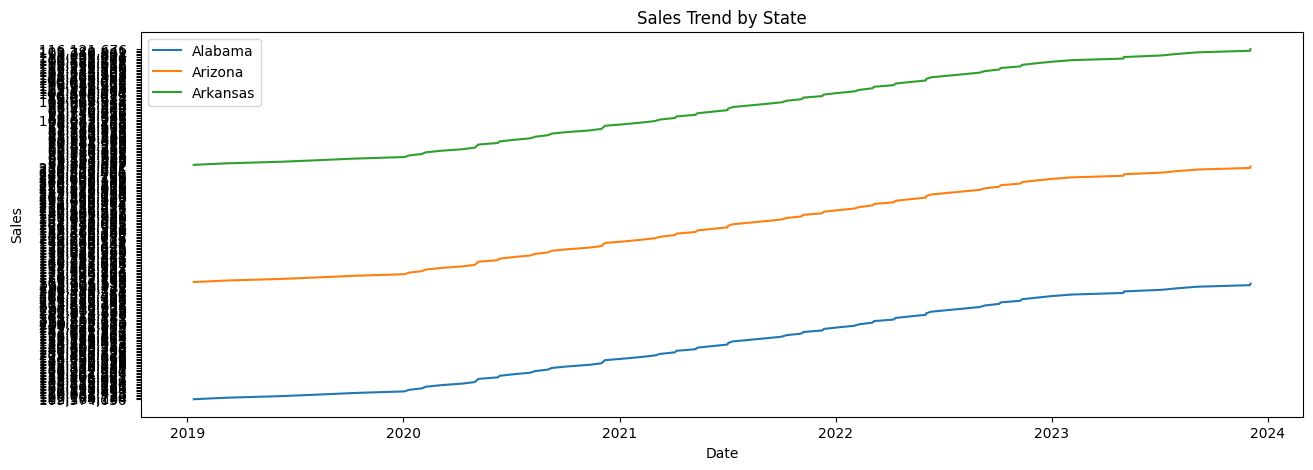

In [23]:
plt.figure(figsize=(15,5))

states = df['state'].unique()[:3]

for state in states:

    temp = df[df['state'] == state]

    plt.plot(
        temp['date'],
        temp['sales'],
        label=state
    )

plt.xlabel("Date")

plt.ylabel("Sales")

plt.title("Sales Trend by State")

plt.legend()

plt.show()

# STEP 12 — CREATE LAG FEATURES

In [24]:
df['lag_1'] = (
    df.groupby('state')['sales']
    .shift(1)
)

df['lag_7'] = (
    df.groupby('state')['sales']
    .shift(7)
)

df['lag_30'] = (
    df.groupby('state')['sales']
    .shift(30)
)

# STEP 13 — CREATE ROLLING FEATURES

In [26]:
# =========================
# CLEAN SALES COLUMN
# =========================

df['sales'] = (
    df['sales']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

# =========================
# CONVERT SALES TO NUMERIC
# =========================

df['sales'] = pd.to_numeric(
    df['sales'],
    errors='coerce'
)

# =========================
# FILL MISSING SALES VALUES
# =========================

df['sales'] = df['sales'].interpolate()

# =========================
# CREATE LAG FEATURES
# =========================

df['lag_1'] = (
    df.groupby('state')['sales']
    .shift(1)
)

df['lag_7'] = (
    df.groupby('state')['sales']
    .shift(7)
)

df['lag_30'] = (
    df.groupby('state')['sales']
    .shift(30)
)

# =========================
# CREATE ROLLING FEATURES
# =========================

df['rolling_mean_7'] = (
    df.groupby('state')['sales']
    .rolling(7)
    .mean()
    .reset_index(0, drop=True)
)

df['rolling_std_7'] = (
    df.groupby('state')['sales']
    .rolling(7)
    .std()
    .reset_index(0, drop=True)
)

# =========================
# CREATE DATE FEATURES
# =========================

df['day_of_week'] = (
    df['date']
    .dt
    .dayofweek
)

df['month'] = (
    df['date']
    .dt
    .month
)

df['week'] = (
    df['date']
    .dt
    .isocalendar()
    .week
    .astype(int)
)

# =========================
# CREATE HOLIDAY FEATURE
# =========================

india_holidays = holidays.India()

df['is_holiday'] = df['date'].apply(
    lambda x: 1 if x in india_holidays else 0
)

# =========================
# REMOVE NULLS CREATED BY LAGS
# =========================

df = df.dropna(subset=[
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_std_7'
])

# =========================
# CHECK DATA
# =========================

print(df.head())

print(df.shape)

        state       date      sales   Category        lag_1        lag_7  \
1290  Alabama 2021-04-04  131843895  Beverages  203436378.0  108717628.0   
1333  Alabama 2021-04-07  150209239  Beverages  131843895.0  117506179.0   
1376  Alabama 2021-05-09  148892734  Beverages  150209239.0  129799793.0   
1419  Alabama 2021-05-12  180600248  Beverages  148892734.0  146096098.0   
1462  Alabama 2021-06-06  140893518  Beverages  180600248.0  134697460.0   

           lag_30  rolling_mean_7  rolling_std_7  day_of_week  month  week  \
1290  109574036.0    1.398158e+08   2.992856e+07            6      4    13   
1333  112189104.0    1.444877e+08   2.837789e+07            2      4    14   
1376  129106730.0    1.472153e+08   2.763881e+07            6      5    18   
1419  108083724.0    1.521444e+08   3.034977e+07            2      5    19   
1462  110932913.0    1.530296e+08   2.984223e+07            6      6    22   

      is_holiday  
1290           0  
1333           0  
1376           0 

# STEP 14 — TRAIN TEST SPLIT

In [27]:
df = df.reset_index(drop=True)

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]

test = df.iloc[split_index:]

# STEP 15 — FEATURES LIST

In [28]:
features = [
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_std_7',
    'day_of_week',
    'month',
    'week',
    'is_holiday'
]

# STEP 16 — CREATE X AND y

In [29]:
X_train = train[features]

y_train = train['sales']

X_test = test[features]

y_test = test['sales']

# STEP 17 — CHECK SHAPES

In [30]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(1548, 9)
(387, 9)
(1548,)
(387,)


# STEP 18 — TRAIN XGBOOST

In [31]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

# STEP 19 — PREDICT

In [32]:
preds = model.predict(X_test)

# STEP 20 — EVALUATE MODEL

In [33]:
mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

print("MAE:", mae)

print("RMSE:", rmse)

MAE: 9094625.0
RMSE: 17367230.30839126


# STEP 21 — PLOT PREDICTIONS

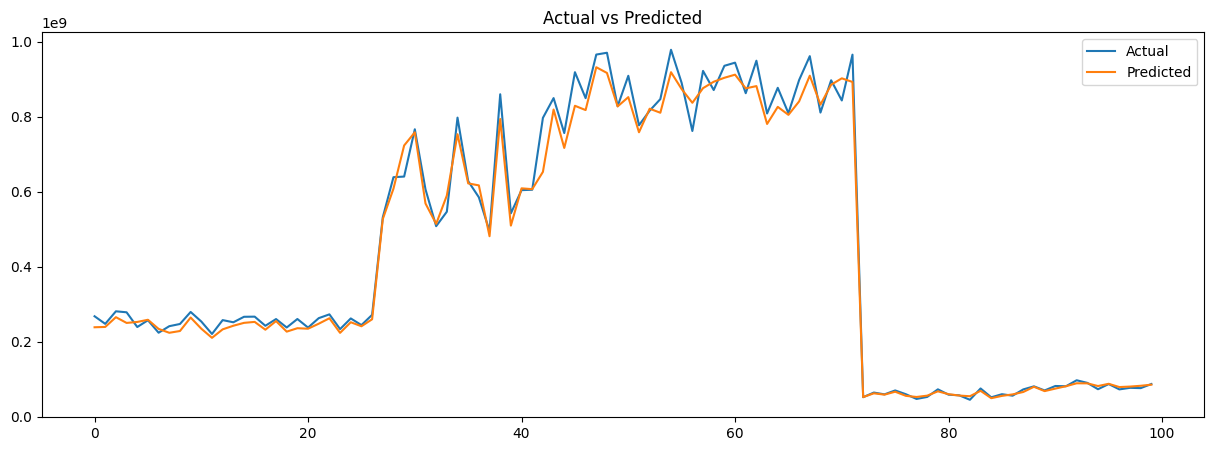

In [34]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test.values[:100],
    label='Actual'
)

plt.plot(
    preds[:100],
    label='Predicted'
)

plt.legend()

plt.title("Actual vs Predicted")

plt.show()

# STEP 22 — SAVE MODEL

In [35]:
import joblib

joblib.dump(
    model,
    'best_model.pkl'
)

['best_model.pkl']

# STEP 23 — DOWNLOAD MODEL

In [36]:
from google.colab import files

files.download('best_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>